<a href="https://colab.research.google.com/github/gui-o-correa/aulas_datascience/blob/master/C%C3%B3pia_de_acc79f175.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔦 OPERAÇÃO FAROL
### Desafio 1 · Trilha de Dados Tabulares · Olimpíada de IA Aplicada 2026

---

> **"Todo ano eu perco alunos. E quase sempre eu só percebo quando a cadeira já está vazia.
> A informação estava comigo o tempo inteiro. O que faltou foi capacidade de processá-la."**
>
> — Marina Alencar, coordenadora pedagógica

---

<img src="https://lh3.googleusercontent.com/d/1QNwaZlOo9zOd-2Y6BF9ljrfdRNJErA-_=w1600" width="100%"
     alt="Sala de coordenação escolar à noite: Marina, de óculos, diante de um monitor antigo que ilumina seu rosto em ciano. Atrás dela, um mural com fotos de turmas, algumas marcadas com um X.">


## 📨 Uma mensagem chegou para a sua equipe

*São 21h47. O computador da sua equipe apita. Mensagem nova.*

---

**De:** Marina Alencar · Coordenação Pedagógica
**Para:** Equipe de Inteligência de Dados
**Assunto:** Preciso da ajuda de vocês. Urgente.

> Sou coordenadora pedagógica de uma instituição com alguns milhares de estudantes
> matriculados. Procuro vocês por causa de um problema que se repete todo ano e que eu não
> consigo mais tratar com os instrumentos que tenho.
>
> Uma estudante deixou de frequentar há três semanas. Quando fui atrás, reconstruí o
> percurso: a taxa de aprovação dela caiu já no primeiro semestre, as notas acompanharam a
> queda no segundo, e havia uma pendência de mensalidade em aberto desde março. **Cada um
> desses dados já estava registrado nos nossos sistemas.** O que não existia era alguém
> capaz de cruzar milhares de fichas por dezenas de variáveis com a frequência necessária
> para agir a tempo.
>
> É um problema de escala, não de informação.
>
> Preciso ser precisa sobre o que estou pedindo, porque a diferença importa. **Não quero um
> sistema que classifique estudantes.** Quero um instrumento de priorização: algo que
> ordene onde a minha atenção limitada rende mais em determinada semana. A decisão sobre o
> que fazer com cada caso continua sendo minha e da equipe pedagógica.
>
> Envio em anexo os dados anonimizados: desempenho acadêmico por semestre, idade na
> matrícula, curso, turno, situação financeira, escolaridade e ocupação dos responsáveis e
> outras variáveis. Sem nomes, sem identificadores. Apenas os indicadores.
>
> Uma ressalva que faço desde já, e que espero que vocês levem a sério: um instrumento
> desses erra. Preciso saber **como** ele erra antes de considerar usá-lo.
>
> — Marina Alencar

---

*O anexo tem 3.236 linhas e 35 variáveis. Vocês têm uma semana.*


## 🎯 A sua missão

Vocês vão construir um modelo de Inteligência Artificial que, olhando os sinais de cada
estudante, sinalize o **risco de evasão** em três níveis: **baixo**, **médio** ou **alto**.

A infraestrutura de código já está montada. O que se exige de vocês é o que não pode ser
automatizado: **decidir com critério, interpretar os resultados e reconhecer os limites do
que foi construído.**

Uma observação metodológica antes de começar. O problema que a Marina traz é de
**classificação supervisionada**: existe um conjunto de casos com resposta conhecida, e a
tarefa é induzir, a partir deles, uma regra que generalize para casos novos. A palavra
central aí é *generalizar*. Um modelo que reproduz perfeitamente o que já viu, mas falha
diante do que não viu, não tem valor prático. Boa parte das decisões de vocês neste caderno
existe para proteger essa capacidade de generalização.

### 🗺️ O mapa da operação

| Bloco | O que vocês fazem | Como |
|:---|:---|:---|
| **1 · EXPLORAR** | Conhecer os estudantes da Marina e procurar pistas | Só clicando |
| **2 · CONFIGURAR** | Decidir como o modelo vai aprender | Só arrastando |
| **3 · MODELAR** | Ensinar o modelo e fazer as previsões | ✏️ Completando o código |
| **4 · AVALIAR** | Descobrir se o farol funciona e o que ele enxerga | Só clicando |

> ⚠️ **Antes de começar:** vá em `Ambiente de execução` → `Alterar o tipo de ambiente de
> execução` e confirme que está em **CPU**. Esta operação inteira roda em segundos, sem
> precisar de placa de vídeo. É assim que garantimos que todas as equipes do Brasil
> compitam em pé de igualdade.
>
> Use `Arquivo` → `Salvar uma cópia no Drive` antes de começar, para não perder o trabalho.

In [ ]:
#@title 🛠️ Preparação: carregando os dados da Marina { display-mode: "form" }
# Endereços oficiais dos dados. A organização republica aqui se precisar trocar.
URL_TREINO = "https://drive.google.com/uc?export=download&id=1j9hXiDzF-h6L6vBxT6fT_XQqy-eMkmVi"
URL_TESTE = "https://drive.google.com/uc?export=download&id=1qxYUo-M23BEtiQTAcMGUh8Tz4--qCzNx"

import pathlib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

NOMES = {0: "Baixo", 1: "Médio", 2: "Alto"}
CORES = ["#3DCB55", "#FFC107", "#E6177A"]


def _carregar(url, nome_local):
    """Baixa do endereço oficial; se a rede falhar, usa cópia local ou pede envio."""
    print(f"Baixando {nome_local}...")
    try:
        return pd.read_csv(url)
    except Exception as erro:
        print(f"  não deu certo ({erro.__class__.__name__}).")
        if not pathlib.Path(nome_local).exists():
            from google.colab import files
            print(f"  envie o arquivo {nome_local}:")
            files.upload()
        return pd.read_csv(nome_local)


# Conjunto PÚBLICO: vocês têm as respostas. Serve para treinar e validar.
dados = _carregar(URL_TREINO, "treino.csv")

# Conjunto de TESTE: tamanho fixo, respostas ocultas. É contra ele que a
# plataforma compara a submissão de todas as equipes.
_teste = _carregar(URL_TESTE, "teste.csv")
IDS_TESTE = _teste["id_estudante"].to_numpy()
dados_teste = _teste.drop(columns=["id_estudante"])
N_TESTE = len(dados_teste)

print("Ambiente carregado.\n")
print(f"  Conjunto público (com respostas) .... {len(dados):>5} estudantes")
print(f"  Conjunto de teste (sem respostas) ... {len(dados_teste):>5} estudantes  [tamanho fixo]")
print(f"  Variáveis disponíveis ............... {dados.shape[1]-1}\n")
print("  O conjunto de teste tem tamanho FIXO e igual para todas as equipes.")
print("  A submissão de vocês precisará ter exatamente", N_TESTE, "linhas.\n")
display(dados.head())

Baixando treino.csv...
Baixando teste.csv...
Ambiente carregado.

  Conjunto público (com respostas) ....  3236 estudantes
  Conjunto de teste (sem respostas) ...  1078 estudantes  [tamanho fixo]
  Variáveis disponíveis ............... 35

  O conjunto de teste tem tamanho FIXO e igual para todas as equipes.
  A submissão de vocês precisará ter exatamente 1078 linhas.



,solteiro,genero,idade_na_matricula,escolaridade_mae,escolaridade_pai,ocupacao_mae,ocupacao_pai,bolsista,devedor,mensalidades_em_dia,...,curso_equinocultura,curso_gestao,curso_gestao_noturno,curso_higiene_oral,curso_jornalismo,curso_publicidade_marketing,curso_servico_social,curso_servico_social_noturno,curso_turismo,risco_evasao
0,1,0,31,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,1,0,0
1,0,0,42,0,0,1,1,0,1,0,...,0,1,0,0,0,0,0,0,0,2
2,1,0,19,0,1,3,2,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,22,0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,38,0,0,1,1,0,0,1,...,0,0,1,0,0,0,0,0,0,2


---
# 🔍 BLOCO 1 · EXPLORAR
## *Antes de acender o farol, é preciso conhecer o terreno*

> **Marina:** *"Cada linha desse arquivo é uma pessoa. Peço que vocês não percam isso de
> vista enquanto olham para os números."*

Esta etapa não exige código. Exige algo mais difícil: formular hipóteses antes de testá-las.

Antes de treinar qualquer modelo, um analista competente examina a distribuição das
variáveis e o equilíbrio entre as classes. Isso não é formalidade. Duas coisas que vocês
vão descobrir aqui determinam decisões técnicas mais adiante: **como as classes estão
distribuídas** (que define qual métrica faz sentido) e **quais variáveis discriminam os
grupos** (que dá a vocês uma expectativa contra a qual comparar o que o modelo aprender).


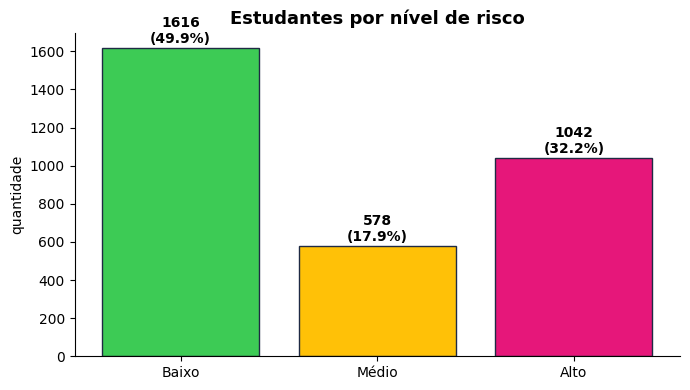

OBSERVAÇÃO METODOLÓGICA
   As três classes têm frequências desiguais. Isso se chama DESBALANCEAMENTO
   DE CLASSES e tem consequência direta sobre a avaliação e sobre o treino.
   Um classificador trivial, que atribuísse a classe majoritária a todos os
   casos, alcançaria acurácia alta sem nenhuma utilidade prática.
   Guardem isto: existe um parâmetro, documentado no Bloco 2, que instrui o
   modelo a compensar esse desequilíbrio durante o treino.


In [ ]:
#@title 📊 Como as três classes estão distribuídas { display-mode: "form" }
contagem = dados["risco_evasao"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([NOMES[i] for i in contagem.index], contagem.values, color=CORES,
       edgecolor="#1F2A44")
for i, v in enumerate(contagem.values):
    ax.text(i, v + 25, f"{v}\n({v/len(dados)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_title("Estudantes por nível de risco", fontsize=13, fontweight="bold")
ax.set_ylabel("quantidade"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("OBSERVAÇÃO METODOLÓGICA")
print("   As três classes têm frequências desiguais. Isso se chama DESBALANCEAMENTO")
print("   DE CLASSES e tem consequência direta sobre a avaliação e sobre o treino.")
print("   Um classificador trivial, que atribuísse a classe majoritária a todos os")
print("   casos, alcançaria acurácia alta sem nenhuma utilidade prática.")
print("   Guardem isto: existe um parâmetro, documentado no Bloco 2, que instrui o")
print("   modelo a compensar esse desequilíbrio durante o treino.")

Variável: taxa_aprovacao_2sem  |  distintos: 52  |  tipo: CONTÍNUA


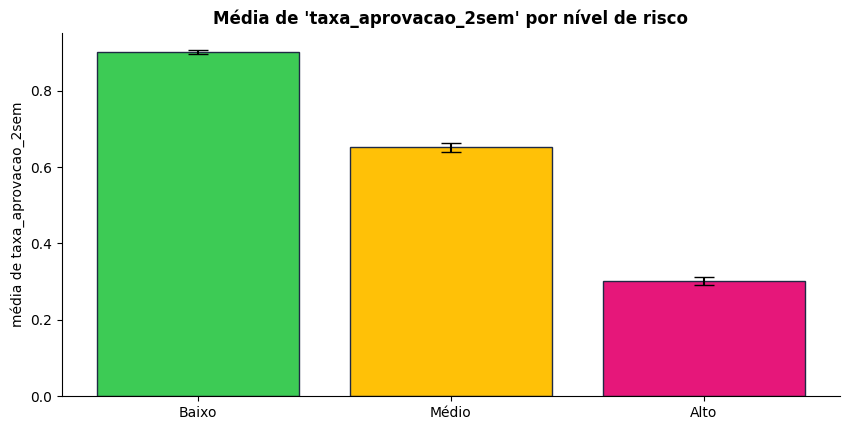


Média de 'taxa_aprovacao_2sem' por grupo:
   Baixo  0.90
   Médio  0.65
   Alto   0.30

Separação entre risco alto e baixo: -0.60
   Separação estatística não implica causalidade.

SUGESTÃO: use a Dispersão para cruzar duas variáveis e procurar INTERAÇÕES.


In [ ]:
#@title 🔬 Investigue os dados: escolha a variável E o tipo de gráfico { display-mode: "form" }
#@markdown Escreva o nome da variável, escolha o gráfico e rode a célula (▶).
#@markdown Rodando de novo com outra escolha, o gráfico é refeito.
variavel = "taxa_aprovacao_2sem"  #@param {type:"string"}
tipo_de_grafico = "Barras de media"  #@param ["Boxplot", "Histograma sobreposto", "Violino", "Barras de media", "Barras de proporcao", "Dispersao contra outra variavel"]
segunda_variavel = "uc_2sem_nota_media"  #@param {type:"string"}

# Sem dropdown de colunas: no Colab a lista teria de ser fixa e quebraria a cada
# troca de dataset. O nome digitado é conferido contra o arquivo.
for _nome in (variavel, segunda_variavel):
    if _nome not in dados.columns:
        raise ValueError(
            f"'{_nome}' não existe no arquivo. Variáveis disponíveis:\n  "
            + "\n  ".join(c for c in dados.columns if c != "risco_evasao"))

serie = dados[variavel]
eh_categorica = serie.nunique() <= 6
grupos = [dados[dados.risco_evasao == k][variavel] for k in [0, 1, 2]]
rotulos = [NOMES[k] for k in [0, 1, 2]]
INCOMPATIVEL = {
    ("Histograma sobreposto", True): "histograma pressupõe variável contínua",
    ("Violino", True): "o violino estima curva de densidade contínua",
    ("Boxplot", True): "boxplot resume quartis, pouco informativos para poucos valores",
    ("Barras de proporcao", False): "proporção exige variável com poucos valores distintos",
}
aviso = INCOMPATIVEL.get((tipo_de_grafico, eh_categorica))
print(f"Variável: {variavel}  |  distintos: {serie.nunique()}  |  "
      f"tipo: {'CATEGÓRICA/DISCRETA' if eh_categorica else 'CONTÍNUA'}")
if aviso:
    print(f"\n[!] ATENÇÃO: {tipo_de_grafico} não é ideal aqui, porque {aviso}.")
    sugestao = "Barras de proporcao" if eh_categorica else "Boxplot, Violino ou Histograma"
    print(f"    Prefira: {sugestao}. O gráfico é exibido assim mesmo.\n")

fig, ax = plt.subplots(figsize=(8.6, 4.4))
if tipo_de_grafico == "Boxplot":
    bp = ax.boxplot(grupos, patch_artist=True, tick_labels=rotulos,
                    medianprops=dict(color="black", linewidth=2))
    for p, c in zip(bp["boxes"], CORES): p.set_facecolor(c); p.set_alpha(.8)
    ax.set_ylabel(variavel)
    ax.set_title(f"'{variavel}' por nível de risco (mediana, quartis e extremos)", fontweight="bold")
elif tipo_de_grafico == "Histograma sobreposto":
    bins = np.histogram_bin_edges(serie, bins=25)
    for g, c, r in zip(grupos, CORES, rotulos):
        ax.hist(g, bins=bins, alpha=.55, label=r, color=c, edgecolor="white")
    ax.legend(title="risco"); ax.set_xlabel(variavel); ax.set_ylabel("quantidade")
    ax.set_title(f"Distribuição de '{variavel}' por nível de risco", fontweight="bold")
elif tipo_de_grafico == "Violino":
    vp = ax.violinplot(grupos, showmedians=True)
    for corpo, c in zip(vp["bodies"], CORES): corpo.set_facecolor(c); corpo.set_alpha(.75)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(rotulos); ax.set_ylabel(variavel)
    ax.set_title(f"Densidade de '{variavel}' por nível de risco", fontweight="bold")
elif tipo_de_grafico == "Barras de media":
    medias_v = [g.mean() for g in grupos]
    erros_v = [g.std()/np.sqrt(len(g)) for g in grupos]
    ax.bar(rotulos, medias_v, yerr=erros_v, capsize=7, color=CORES, edgecolor="#1F2A44")
    ax.set_ylabel(f"média de {variavel}")
    ax.set_title(f"Média de '{variavel}' por nível de risco", fontweight="bold")
elif tipo_de_grafico == "Barras de proporcao":
    tab = pd.crosstab(dados[variavel], dados.risco_evasao, normalize="index") * 100
    base = np.zeros(len(tab))
    for k, c in zip([0, 1, 2], CORES):
        vals = tab[k].values if k in tab.columns else np.zeros(len(tab))
        ax.bar(tab.index.astype(str), vals, bottom=base, color=c, label=NOMES[k], edgecolor="white")
        base += vals
    ax.set_xlabel(variavel); ax.set_ylabel("% dentro de cada valor")
    ax.legend(title="risco", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(f"Composição do risco dentro de cada valor de '{variavel}'", fontweight="bold")
else:
    for k, c in zip([0, 1, 2], CORES):
        sub = dados[dados.risco_evasao == k]
        ax.scatter(sub[variavel], sub[segunda_variavel], s=14, alpha=.55,
                   color=c, label=NOMES[k], edgecolors="none")
    ax.set_xlabel(variavel); ax.set_ylabel(segunda_variavel)
    ax.legend(title="risco")
    ax.set_title(f"'{variavel}' contra '{segunda_variavel}'", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

medias_g = dados.groupby("risco_evasao")[variavel].mean()
print(f"\nMédia de '{variavel}' por grupo:")
for k in [0, 1, 2]: print(f"   {NOMES[k]:<6} {medias_g[k]:.2f}")
print(f"\nSeparação entre risco alto e baixo: {medias_g[2]-medias_g[0]:+.2f}")
print("   Separação estatística não implica causalidade.")
print("\nSUGESTÃO: use a Dispersão para cruzar duas variáveis e procurar INTERAÇÕES.")

> **Marina:** *"Vocês já sabem mais sobre a distribuição desses dados do que eu soube em
> quatro anos de coordenação. Sigam."*

<img src="https://lh3.googleusercontent.com/d/1Y0ZszuQKso_xSGRx0yYA1ekGMKplyqDq=w1600" width="100%"
     alt="Quatro jovens de costas diante de uma parede de vidro coberta por gráficos, mapas e redes de pontos em azul e ciano. Um deles aponta para uma linha vermelha em destaque.">


---
# ⚙️ BLOCO 2 · CONFIGURAR
## *As decisões que definem o desempenho*

### Como os dados estão organizados

Existem dois conjuntos, e a diferença entre eles é fundamental:

| Conjunto | Tamanho | Vocês têm as respostas? | Para que serve |
|:---|:---|:---|:---|
| **Público** | 3.236 | Sim | Treinar o modelo e validar as escolhas de vocês |
| **Teste** | **1.078 (fixo)** | Não | Comparação oficial entre todas as equipes |

O conjunto público é dividido em duas partes: uma para **treinar** e outra para
**validar**. A parte de validação funciona como um simulado, com o gabarito em mãos,
que permite estimar o desempenho antes da submissão.

O conjunto de teste tem **tamanho fixo e idêntico para todas as equipes**. É contra ele
que a plataforma compara a submissão de vocês, e por isso o arquivo enviado precisa ter
exatamente 1.078 linhas. A célula de submissão verifica isso automaticamente.

**O que o controle abaixo define:** que fatia do conjunto público fica reservada para
validação. Um valor alto dá uma estimativa mais estável, mas deixa menos exemplos para o
modelo aprender. Um valor baixo faz o oposto. O compromisso é de vocês.


In [ ]:
#@title 🎛️ Parâmetros do experimento { display-mode: "form" }
#@markdown Ajuste os controles e rode a célula (▶) para registrar a configuração.
tamanho_da_validacao = 10  #@param {type:"slider", min:10, max:40, step:5}
modelo_escolhido = "Floresta Aleatoria"  #@param ["Arvore de Decisao", "Floresta Aleatoria", "Regressao Logistica"]
profundidade = 10  #@param {type:"slider", min:2, max:24, step:1}
n_arvores = 500  #@param {type:"slider", min:50, max:600, step:50}

n_treino = int(len(dados) * (1 - tamanho_da_validacao/100))
n_valida = len(dados) - n_treino
print("PARÂMETROS DEFINIDOS")
print(f"   Validação: {tamanho_da_validacao}%  ({n_valida} estudantes)")
print(f"   Treino: {100-tamanho_da_validacao}%  ({n_treino} estudantes)")
print(f"   Teste: {len(dados_teste)} estudantes  [FIXO para todas as equipes]")
print(f"   Modelo: {modelo_escolhido}")
print(f"   Profundidade: {profundidade}")
if modelo_escolhido == "Floresta Aleatoria":
    print(f"   Árvores: {n_arvores}")
print("\nConfiguração registrada. Ela será usada nas próximas células.")

PARÂMETROS DEFINIDOS
   Validação: 10%  (324 estudantes)
   Treino: 90%  (2912 estudantes)
   Teste: 1078 estudantes  [FIXO para todas as equipes]
   Modelo: Floresta Aleatoria
   Profundidade: 10
   Árvores: 400

Configuração registrada. Ela será usada nas próximas células.


### Os três modelos disponíveis

| Modelo | Princípio de funcionamento | Compromisso |
|:---|:---|:---|
| **Árvore de Decisão** | Particiona o espaço por cortes sucessivos em uma variável de cada vez | Altamente interpretável; instável e propensa a sobreajuste |
| **Floresta Aleatória** | Combina centenas de árvores treinadas em subamostras distintas e agrega por votação | Desempenho superior e mais estável; interpretação individual se perde |
| **Regressão Logística** | Estima um coeficiente por variável e combina linearmente | Estável e transparente; incapaz de captar interações não lineares |

---

### 📗 Referência técnica: nome exato e parâmetros de cada modelo

**Vocês vão precisar desta tabela no Bloco 3.** Ela traz o nome exato da classe de cada
modelo e os parâmetros que ela aceita, com o valor que cada parâmetro assume quando **não
é declarado** (o valor padrão).

> **Por que isso importa.** No Bloco 3, o código traz apenas alguns parâmetros preenchidos.
> Todos os demais assumem silenciosamente o valor padrão listado abaixo. Uma equipe que
> apenas completa o nome da classe obtém um resultado correto, porém mediano. Uma equipe
> que estuda esta tabela e **acrescenta parâmetros à chamada** consegue resultados
> consistentemente melhores. Essa diferença é intencional.

#### 🌳 Árvore de Decisão

```python
from sklearn.tree import DecisionTreeClassifier
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `criterion` | `'gini'` | Medida de impureza usada para escolher os cortes. Alternativa: `'entropy'` |
| `splitter` | `'best'` | Como escolher o corte. `'random'` introduz aleatoriedade |
| `max_depth` | `None` | Profundidade máxima. `None` cresce até as folhas ficarem puras, o que quase sempre gera sobreajuste |
| `min_samples_split` | `2` | Mínimo de amostras para dividir um nó. Valores maiores contêm o sobreajuste |
| `min_samples_leaf` | `1` | Mínimo de amostras em cada folha. Aumentar suaviza o modelo |
| `max_features` | `None` | Quantas variáveis considerar por corte. Aceita número, fração ou `'sqrt'` |
| `class_weight` | `None` | Peso de cada classe. **`'balanced'` compensa o desbalanceamento automaticamente** |
| `max_leaf_nodes` | `None` | Teto de folhas. Alternativa a `max_depth` para limitar complexidade |
| `min_impurity_decrease` | `0.0` | Ganho mínimo exigido para aceitar um corte |
| `ccp_alpha` | `0.0` | Poda por complexidade de custo. Valores pequenos (0.001 a 0.02) podam a árvore |
| `random_state` | `None` | Semente. Fixar garante reprodutibilidade |

#### 🌲 Floresta Aleatória

```python
from sklearn.ensemble import RandomForestClassifier
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `n_estimators` | `100` | Número de árvores. Mais árvores estabilizam o resultado e custam tempo |
| `criterion` | `'gini'` | Igual à árvore. Alternativa: `'entropy'` |
| `max_depth` | `None` | Profundidade máxima de cada árvore |
| `min_samples_split` | `2` | Mínimo de amostras para dividir um nó |
| `min_samples_leaf` | `1` | Mínimo de amostras por folha |
| `max_features` | `'sqrt'` | Variáveis sorteadas por corte. Aceita fração, por exemplo `0.5` |
| `bootstrap` | `True` | Se cada árvore usa uma reamostragem com reposição |
| `oob_score` | `False` | Estima o erro com as amostras deixadas de fora de cada árvore |
| `class_weight` | `None` | **`'balanced'` ou `'balanced_subsample'` compensam o desbalanceamento** |
| `max_samples` | `None` | Fração do conjunto usada por árvore quando `bootstrap=True` |
| `ccp_alpha` | `0.0` | Poda por complexidade de custo |
| `n_jobs` | `None` | Núcleos usados. `-1` usa todos e acelera bastante |
| `random_state` | `None` | Semente |

#### 📈 Regressão Logística

```python
from sklearn.linear_model import LogisticRegression
```

| Parâmetro | Padrão | O que faz |
|:---|:---|:---|
| `penalty` | `'l2'` | Tipo de regularização. Aceita `'l1'`, `'l2'`, `'elasticnet'`, `None` |
| `C` | `1.0` | Inverso da força da regularização. **Menor que 1 regulariza mais**; maior ajusta mais aos dados |
| `solver` | `'lbfgs'` | Algoritmo de otimização. `'liblinear'` e `'saga'` aceitam `'l1'` |
| `max_iter` | `100` | Iterações máximas. Frequentemente insuficiente: sem aumentar, o ajuste pode não convergir |
| `class_weight` | `None` | **`'balanced'` compensa o desbalanceamento** |
| `fit_intercept` | `True` | Se estima o termo constante |
| `tol` | `0.0001` | Tolerância do critério de parada |
| `random_state` | `None` | Semente |

> 💡 **Leiam a coluna de padrões com atenção.** Reparem, por exemplo, que `class_weight`
> vem como `None` nos três modelos, ou seja, **por omissão nenhum deles compensa o
> desbalanceamento** que vocês identificaram no Bloco 1.

---
# ✏️ BLOCO 3 · MODELAR
## *Aqui vocês escrevem código*

Esta etapa exige três coisas de vocês: **saber o nome exato de cada classe** (está na
referência do Bloco 2), **saber montar a estrutura condicional** que escolhe o modelo, e
**saber a sequência correta de operações**.

### A interface comum dos estimadores

A biblioteca `scikit-learn` adota uma convenção uniforme: todo estimador expõe a mesma
interface, o que permite trocar de algoritmo sem reescrever o restante do código.

| Método | Operação | Onde se aplica |
|:---|:---|:---|
| `.fit(X, y)` | **Ajusta** os parâmetros internos a partir dos exemplos e das respostas | Exclusivamente no conjunto de treino |
| `.predict(X)` | **Infere** a classe de casos novos, com os parâmetros já ajustados | Na validação e no teste |

Convenção de notação: **`X`** é a matriz de variáveis preditoras e **`y`** o vetor da
variável resposta. A ordem é obrigatória: sem `fit` prévio, não há parâmetros para
`predict` utilizar.

### Sobre a estrutura condicional

O trecho abaixo precisa escolher um entre três modelos conforme a opção marcada no
Bloco 2. Isso se faz com uma cadeia `if` / `elif` / `else`. Reparem que `else` não recebe
condição, apenas os dois-pontos.

> ⚠️ **A célula não executa enquanto houver lacunas.** Isso é esperado: preencham primeiro,
> executem depois.


In [ ]:
# ✏️ SUA VEZ · Parte 1: separar os dados e construir o modelo

X = dados.drop(columns=["risco_evasao"])
y = dados["risco_evasao"]

# Divisão dos dados
X_treino, X_valida, y_treino, y_valida = train_test_split(
    X,
    y,
    test_size=tamanho_da_validacao/100,
    random_state=42,
    stratify=y
)

if modelo_escolhido == "Arvore de Decisao":
    modelo = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )

elif modelo_escolhido == "Floresta Aleatoria":
    modelo = RandomForestClassifier(
        n_estimators=450,
        criterion="entropy",
        max_depth=10,
        min_samples_split=23,
        min_samples_leaf=1,
        max_features=0.05,
        bootstrap=False,
        class_weight="balanced",
        ccp_alpha=0.0005,
        random_state=281810381,
        n_jobs=-1
    )

else:
    modelo = LogisticRegression(
        max_iter=2000,
        random_state=42
    )
print(f"Treino:    {len(X_treino)} estudantes")
print(f"Validação: {len(X_valida)} estudantes")
print(f"Modelo construído: {type(modelo).__name__}")

print("tamanho_da_validacao =", tamanho_da_validacao)
print("test_size =", tamanho_da_validacao / 100)
print("modelo_escolhido =", modelo_escolhido)

print(type(modelo).__name__)
print(modelo)

Treino:    2912 estudantes
Validação: 324 estudantes
Modelo construído: RandomForestClassifier
tamanho_da_validacao = 10
test_size = 0.1
modelo_escolhido = Floresta Aleatoria
RandomForestClassifier
RandomForestClassifier(bootstrap=False, ccp_alpha=0.0005,
                       class_weight='balanced', criterion='entropy',
                       max_depth=10, max_features=0.05, min_samples_split=23,
                       n_estimators=450, n_jobs=-1, random_state=281810381)


In [ ]:
# ✏️ SUA VEZ · Parte 2: treinar e prever
# LACUNA 7 ▸ qual método ajusta os parâmetros do modelo ao conjunto de treino?
modelo.fit(X_treino, y_treino)

# LACUNA 8 ▸ qual método infere as classes de casos que o modelo nunca viu?
previsoes = modelo.predict(X_valida)

print(f"Modelo ajustado. {len(previsoes)} previsões geradas para a validação.")

Modelo ajustado. 324 previsões geradas para a validação.


In [ ]:
#@title 🔎 Verificação das lacunas { display-mode: "form" }
erros = []

# estratificação
try:
    p_total = np.bincount(y, minlength=3) / len(y)
    p_treino = np.bincount(y_treino, minlength=3) / len(y_treino)
    if np.abs(p_total - p_treino).max() > 0.03:
        erros.append("LACUNA 1: as proporções das classes no treino diferem do conjunto "
                     "completo. O argumento 'stratify' não recebeu o vetor correto.")
except NameError:
    erros.append("LACUNA 1: X_treino/y_treino não existem. Rode a Parte 1.")

# classe do modelo
try:
    esperado = {"Arvore de Decisao": "DecisionTreeClassifier",
                "Floresta Aleatoria": "RandomForestClassifier",
                "Regressao Logistica": "LogisticRegression"}[modelo_escolhido]
    obtido = type(modelo).__name__
    if obtido != esperado:
        erros.append(f"LACUNAS 2 a 6: para '{modelo_escolhido}' era esperada a classe "
                     f"{esperado}, mas foi construída {obtido}. Revise os nomes e a "
                     f"cadeia if / elif / else.")
except NameError:
    erros.append("LACUNAS 2 a 6: a variável 'modelo' não existe. Rode a Parte 1.")

# treino e previsão
try:
    if not hasattr(modelo, "classes_"):
        erros.append("LACUNA 7: o modelo não possui parâmetros ajustados. "
                     "Qual método realiza o ajuste aos dados de treino?")
except NameError: pass
try:
    if len(previsoes) != len(X_valida):
        erros.append(f"LACUNA 8: {len(previsoes)} previsões para {len(X_valida)} casos.")
except NameError:
    erros.append("LACUNA 8: a variável 'previsoes' não existe.")

if erros:
    print("VERIFICAÇÃO REPROVADA. Pontos a revisar:\n")
    for e in erros: print("   [!] " + e + "\n")
else:
    print("VERIFICAÇÃO APROVADA\n")
    print("   Pipeline completo: dados estratificados, modelo construído e ajustado,")
    print("   previsões geradas sobre a validação.")
    extras = {k: v for k, v in modelo.get_params().items()
              if k in ("class_weight","min_samples_leaf","max_features","C","ccp_alpha",
                       "criterion","max_leaf_nodes","min_samples_split")
              and v not in (None, 1, 2, 0.0, "gini", "sqrt", 1.0)}
    if extras:
        print(f"\n   Parâmetros adicionais detectados na ZONA LIVRE: {extras}")
        print("   Boa. Comparem o resultado com e sem eles.")
    else:
        print("\n   Nenhum parâmetro adicional foi declarado: o modelo está usando os")
        print("   valores padrão. Isso é válido e produz um resultado correto, mas as")
        print("   tabelas do Bloco 2 oferecem margem real de melhoria.")

VERIFICAÇÃO APROVADA

   Pipeline completo: dados estratificados, modelo construído e ajustado,
   previsões geradas sobre a validação.

   Parâmetros adicionais detectados na ZONA LIVRE: {'ccp_alpha': 0.0005, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_features': 0.05, 'min_samples_split': 23}
   Boa. Comparem o resultado com e sem eles.


---
# 📈 BLOCO 4 · AVALIAR
## *O farol funciona mesmo?*

> **Marina:** *"Antes de eu levar isso para a equipe pedagógica, preciso de duas
> informações: quanto ele acerta e, principalmente, de que forma ele erra."*

### Por que a acurácia é insuficiente aqui

Acurácia é a proporção de acertos sobre o total. Em conjuntos desbalanceados, ela é
enganosa. Considerem o classificador degenerado que atribui "risco baixo" a todos os casos:
sem aprender nada, ele alcançaria acurácia próxima da frequência da classe majoritária, ao
custo de nunca identificar um único estudante em risco alto. Ou seja, obteria um número
respeitável executando exatamente o oposto da tarefa.

Por isso a métrica oficial deste desafio é o **F1-macro**. Ele é calculado assim: para cada
classe, computa-se a média harmônica entre **precisão** (das vezes que o modelo apontou
esta classe, quantas estavam certas) e **revocação** (dos casos que realmente pertenciam a
esta classe, quantos o modelo encontrou). Depois, tira-se a média simples entre as classes.

A média simples é o ponto decisivo: ela dá o mesmo peso à classe de risco alto e à classe
majoritária, embora uma tenha uma fração dos casos da outra. É essa propriedade que torna a
métrica adequada ao problema da Marina.


            DESEMPENHO NO CONJUNTO DE VALIDAÇÃO
  Acurácia .............................  79.6%
  F1-MACRO (métrica oficial) ...........  76.0%
  Desempenho alto. Verifiquem a estabilidade mudando a validação.


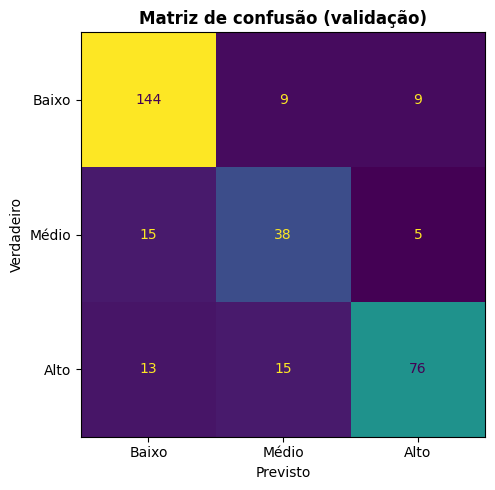


LEITURA DA MATRIZ:
   A diagonal principal concentra as classificações corretas.
   Os elementos fora da diagonal indicam a DIREÇÃO de cada erro.
   Observem a última linha: casos de risco alto classificados como baixo são
   FALSOS NEGATIVOS na classe crítica, e têm custo assimétrico.

              precision    recall  f1-score   support

       Baixo      0.837     0.889     0.862       162
       Médio      0.613     0.655     0.633        58
        Alto      0.844     0.731     0.784       104

    accuracy                          0.796       324
   macro avg      0.765     0.758     0.760       324
weighted avg      0.799     0.796     0.796       324



In [ ]:
#@title 🏆 Desempenho na validação { display-mode: "form" }
acuracia = accuracy_score(y_valida, previsoes)
f1 = f1_score(y_valida, previsoes, average="macro")

print("="*60)
print("            DESEMPENHO NO CONJUNTO DE VALIDAÇÃO")
print("="*60)
print(f"  Acurácia ............................. {acuracia*100:5.1f}%")
print(f"  F1-MACRO (métrica oficial) ........... {f1*100:5.1f}%")
print("="*60)
# Faixas calibradas neste conjunto: ~69% e o teto observado com boa configuração.
if   f1 >= .68: print("  Desempenho alto. Verifiquem a estabilidade mudando a validação.")
elif f1 >= .63: print("  Desempenho sólido, com margem de otimização no Bloco 2.")
elif f1 >= .57: print("  Desempenho intermediário. Revisem modelo, profundidade e ZONA LIVRE.")
else:           print("  Desempenho baixo. A configuração atual não captura os padrões.")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_valida, previsoes),
    display_labels=["Baixo","Médio","Alto"]).plot(ax=ax, cmap="viridis", colorbar=False)
ax.set_title("Matriz de confusão (validação)", fontweight="bold")
ax.set_xlabel("Previsto"); ax.set_ylabel("Verdadeiro")
plt.tight_layout(); plt.show()

print("\nLEITURA DA MATRIZ:")
print("   A diagonal principal concentra as classificações corretas.")
print("   Os elementos fora da diagonal indicam a DIREÇÃO de cada erro.")
print("   Observem a última linha: casos de risco alto classificados como baixo são")
print("   FALSOS NEGATIVOS na classe crítica, e têm custo assimétrico.\n")
print(classification_report(y_valida, previsoes,
      target_names=["Baixo","Médio","Alto"], digits=3))

if (previsoes == 1).sum() < 0.05 * len(previsoes):
    print("\n[!] O modelo quase não atribuiu a classe 'Médio'. Isso derruba o F1-macro,")
    print("    que dá peso igual às três classes. Revejam o desbalanceamento do Bloco 1")
    print("    e o parâmetro do Bloco 2 que corrige exatamente esse efeito.")

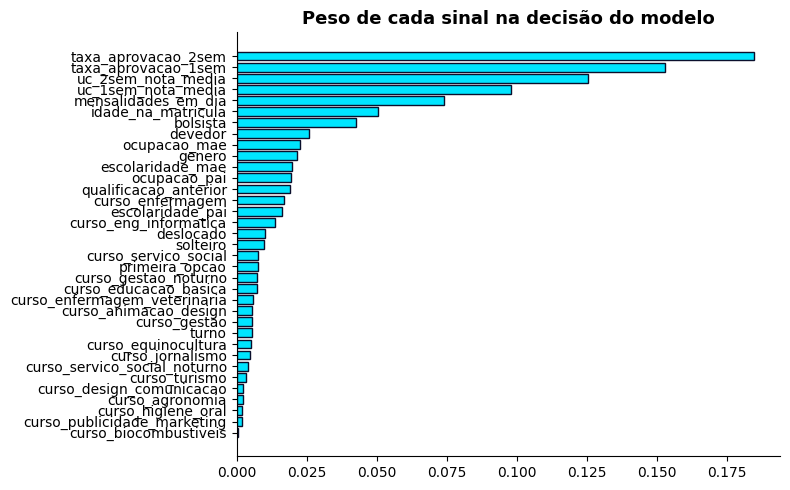

VARIÁVEIS DE MAIOR IMPORTÂNCIA NO MODELO AJUSTADO:

   1. taxa_aprovacao_2sem  (0.185)
   2. taxa_aprovacao_1sem  (0.153)
   3. uc_2sem_nota_media  (0.125)

Ressalva necessária: importância de variável NÃO é evidência de causalidade.
O modelo identifica associação estatística. Uma variável pode ranquear alto
por estar correlacionada com um fator não observado que é a causa real.
Confundir as duas coisas é um erro frequente na interpretação de modelos.


In [ ]:
#@title 🔦 O que o farol está enxergando? { display-mode: "form" }
# A Marina não quer só o alerta. Ela quer entender por quê.

if hasattr(modelo, "feature_importances_"):
    imp = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()
    titulo = "Peso de cada sinal na decisão do modelo"
else:
    imp = pd.Series(np.abs(modelo.coef_).mean(axis=0), index=X.columns).sort_values()
    titulo = "Peso de cada sinal (média dos coeficientes)"

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#00E5FF", edgecolor="#0A0F2C")
ax.set_title(titulo, fontsize=13, fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

top3 = imp.sort_values(ascending=False).head(3)
print("VARIÁVEIS DE MAIOR IMPORTÂNCIA NO MODELO AJUSTADO:\n")
for i, (nome, val) in enumerate(top3.items(), 1):
    print(f"   {i}. {nome}  ({val:.3f})")
print("\nRessalva necessária: importância de variável NÃO é evidência de causalidade.")
print("O modelo identifica associação estatística. Uma variável pode ranquear alto")
print("por estar correlacionada com um fator não observado que é a causa real.")
print("Confundir as duas coisas é um erro frequente na interpretação de modelos.")

---
# 🤔 PARADA OBRIGATÓRIA: uma conversa séria

> **Marina:** *"Antes de fechar, preciso colocar uma questão que não é técnica, mas que
> determina se eu posso ou não usar o que vocês construíram."*
>
> *"O mesmo arquivo que diz 'esse estudante precisa de atenção' também pode ser lido como
> 'esse estudante é um problema'. A saída do modelo é idêntica nos dois casos. O que muda é
> o protocolo institucional em volta dela."*
>
> *"Sistemas de predição de risco aplicados a pessoas produzem um efeito documentado: a
> classificação altera o tratamento, o tratamento altera o resultado, e o resultado acaba
> confirmando a classificação. O modelo passa a validar a si mesmo. Se isso acontecer aqui,
> teremos construído uma profecia, não um diagnóstico."*

### Questões para a equipe deliberar

1. **Sobre o custo assimétrico dos erros.** Um falso positivo consome tempo da equipe
   pedagógica com quem não precisava. Um falso negativo deixa sem apoio quem precisava.
   Qual dos dois vocês priorizariam reduzir, e o que se perde nessa escolha? Note que a
   pergunta não tem resposta técnica: ela depende de um juízo de valor que o modelo não faz.

2. **Sobre variáveis socialmente sensíveis.** Variáveis como `mensalidades_em_dia`,
   `devedor` e `bolsista` costumam aparecer entre as mais relevantes. Elas são, na prática,
   indicadores indiretos de condição socioeconômica — e o mesmo vale para `escolaridade_mae`
   e `ocupacao_pai`. Isso levanta uma questão real da área: um modelo que usa esses
   indicadores aumenta a detecção, mas também concentra a sinalização sobre um grupo já
   vulnerável. Remover a variável resolve o problema ou apenas o torna invisível, já que
   outras variáveis correlacionadas permanecem? **Testem:** retirem essas colunas de `X` no
   Bloco 3, reexecutem e comparem o F1-macro e a matriz de confusão.

3. **Sobre governança.** Que restrições de uso vocês anexariam à entrega? Considerem: quem
   pode acessar a lista, por quanto tempo ela é válida, o que explicitamente não pode ser
   feito com ela, e quem responde por uma decisão tomada com base no modelo.

<img src="https://lh3.googleusercontent.com/d/1tt3Sy_3RapDMyyDio5vU04_moy-o_kuA=w1600" width="100%"
     alt="Farol no alto de uma colina à noite, projetando um feixe dourado sobre um caminho por onde estudantes seguem em direção a uma escola iluminada. Outros permanecem parados no escuro, à margem do feixe.">


In [ ]:
#@title 📝 O relatório da sua equipe para a Marina { display-mode: "form" }
nome_da_equipe = ""  #@param {type:"string"}
#@markdown **1. Por que vocês escolheram esse modelo e essa configuração?**
resposta_1 = ""  #@param {type:"string"}
#@markdown **2. Quais sinais mais pesam no risco de evasão?**
resposta_2 = ""  #@param {type:"string"}
#@markdown **3. Que restrições de uso vocês anexariam à entrega, e por quê?**
resposta_3 = ""  #@param {type:"string"}

relatorio = {"equipe": nome_da_equipe, "modelo": modelo_escolhido,
             "teste_pct": tamanho_da_validacao, "profundidade": profundidade,
             "f1_macro": round(f1, 4), "acuracia": round(acuracia, 4),
             "just_modelo": resposta_1, "just_sinais": resposta_2,
             "just_cuidado": resposta_3}
faltando = [k for k in ["equipe", "just_modelo", "just_sinais", "just_cuidado"]
            if not relatorio[k].strip()]
if faltando:
    print("⚠️ Ainda faltam campos:", ", ".join(faltando))
else:
    print("Relatório completo. Prossigam para a submissão.")

⚠️ Ainda faltam campos: equipe, just_modelo, just_sinais, just_cuidado


In [ ]:
#@title 🚀 Gerar o arquivo de submissão { display-mode: "form" }
#@markdown Rode a célula (▶). Os dois arquivos são baixados automaticamente.
import json, pathlib

PASTA_SUBMISSAO = pathlib.Path("submissoes/tabular")
PASTA_SUBMISSAO.mkdir(parents=True, exist_ok=True)
if "relatorio" not in dir() or not isinstance(relatorio, dict):
    relatorio = {"equipe": "", "modelo": modelo_escolhido,
                 "teste_pct": tamanho_da_validacao, "profundidade": profundidade,
                 "f1_macro": round(f1, 4), "acuracia": round(acuracia, 4),
                 "just_modelo": "", "just_sinais": "", "just_cuidado": ""}

# O modelo é aplicado ao conjunto de teste, cujas respostas ficam com a organização.
palpites = modelo.predict(dados_teste)
# Os ids vêm do próprio arquivo de teste: reinventá-los com arange desalinha a
# submissão do gabarito se a numeração original mudar.
submissao = pd.DataFrame({"id_estudante": IDS_TESTE, "risco_previsto": palpites})

assert len(submissao) == N_TESTE, f"A submissão precisa ter {N_TESTE} linhas."
csv_saida = PASTA_SUBMISSAO / "submissao_tabular.csv"
json_saida = PASTA_SUBMISSAO / "relatorio_tabular.json"
submissao.to_csv(csv_saida, index=False)
with open(json_saida, "w", encoding="utf-8") as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)

print("="*60)
print("             ARQUIVOS PRONTOS PARA ENVIO")
print("="*60)
print(f"  submissao_tabular.csv   ({len(submissao)} linhas)")
print("  relatorio_tabular.json")
print("="*60)
print("\n  Distribuição prevista no teste:")
for k, v in pd.Series(palpites).value_counts().sort_index().items():
    print(f"     {NOMES[k]:<6} {v:>4}  ({v/len(palpites)*100:.1f}%)")
display(submissao.head())

try:
    from google.colab import files
    files.download(str(csv_saida))
    files.download(str(json_saida))
    print("\n  Download iniciado. Enviem os dois arquivos na plataforma.")
except ImportError:
    print(f"\n  Fora do Colab: os arquivos estão em {PASTA_SUBMISSAO.resolve()}")

             ARQUIVOS PRONTOS PARA ENVIO
  submissao_tabular.csv   (1078 linhas)
  relatorio_tabular.json

  Distribuição prevista no teste:
     Baixo   534  (49.5%)
     Médio   201  (18.6%)
     Alto    343  (31.8%)


,id_estudante,risco_previsto
0,0,2
1,1,2
2,2,0
3,3,0
4,4,0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  Download iniciado. Enviem os dois arquivos na plataforma.


---
# 🌟 FIM DA OPERAÇÃO FAROL

> **Marina:** *"Recebi o arquivo e a lista de restrições que vocês anexaram. Levei as duas
> coisas para a reunião pedagógica de segunda."*
>
> *"A discussão que tivemos lá não foi sobre a lista. Foi sobre o que a escola faz com ela,
> e sobre em que ponto a equipe humana entra. Vocês deixaram isso escrito, o que tornou a
> conversa possível."*
>
> *"É um trabalho maduro. Obrigada."*

---

### Competências desenvolvidas neste desafio

- Particionamento entre treino e teste, e a razão estatística por trás dele
- Sobreajuste, subajuste e o compromisso entre viés e variância
- A interface `fit` / `predict` e a lógica de estimadores do `scikit-learn`
- Limitações da acurácia sob desbalanceamento de classes
- Precisão, revocação e a construção do F1-macro
- Leitura direcional da matriz de confusão e custo assimétrico de erros
- Importância de variáveis, e a distinção entre associação e causalidade
- Governança de sistemas preditivos aplicados a pessoas

**Otimização.** Voltem ao Bloco 2 e alterem **um parâmetro por vez**, registrando o efeito
sobre o F1-macro. Variar tudo simultaneamente impede atribuir a melhora a qualquer decisão
específica. Esse método tem nome em experimentação e vale para muito além deste caderno.
